# 04 · ISIC 2018: EIoU vs AEIoU Skin Lesion Detection

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nipun-taneja/amorphous-yolo/blob/main/notebooks/04_isic2018.ipynb)

**Purpose:** Validate AEIoU on ISIC 2018 skin lesion detection — a second amorphous-boundary
dataset independent of Kvasir-SEG. Skin lesions share the same high boundary-ambiguity
property as colorectal polyps, making this an ideal replication study.

**Structure:** Identical training infrastructure to notebook 03. Only the dataset changes.

**Expected result:** Best AEIoU λ (≈0.3–0.5) should outperform all baselines on the clean
split and show improved noise robustness on low/high perturbation splits.

**Runtime:** ~18 h on an A100 (33 runs × 20 epochs each). Use Colab A100 runtime.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Section 1 · Environment Setup

**Requirements**
- Google Colab with A100 GPU (recommended) or T4 GPU
- Colab Secrets: `WANDB_API_KEY` (optional — WandB is silently disabled if absent)
- ~15 GB disk space (ISIC images + model weights + experiment runs)

**Steps:**
1. Run pip install (Cell 2)
2. Run git clone (Cell 3)
3. Run constants (Cell 4)
4. Run WandB login (Cell 5)
5. Run Drive mount + restore (Cell 7) — restores completed runs after restart
6. Run dataset download + label conversion (Cells 8–10)
7. Run training grids (Cells 22–25)
8. Run analysis (Section 9+)

In [2]:
# --- Install pinned dependencies
# ultralytics 8.4.9: confirmed working with yolo26n.pt and our monkey-patch
# wandb 0.24.1: optional experiment tracking (silently skipped if no API key)
!pip install --upgrade pip -q
!pip install -U "ultralytics==8.4.9" "wandb==0.24.1" -q
print("Dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 47.0 MB/s eta 0:00:00
Dependencies installed.


In [3]:
# --- Idempotent git clone
# Safe to re-run: skips the clone if the repo is already present.
# The repo contains src/losses.py (EIoULoss, AEIoULoss) and the data/ yaml files.
import os, sys

REPO_PATH = "/content/amorphous-yolo"
if not os.path.exists(f"{REPO_PATH}/.git"):
    print("Cloning amorphous-yolo...")
    os.system(f"git clone https://github.com/nipun-taneja/amorphous-yolo.git {REPO_PATH}")
else:
    print("Repo already present — skipping clone.")

# Add project root to Python path so src.losses is importable
if REPO_PATH not in sys.path:
    sys.path.insert(0, REPO_PATH)

os.chdir(REPO_PATH)
print(f"Working directory: {os.getcwd()}")

Cloning amorphous-yolo...
Working directory: /content/amorphous-yolo


In [4]:
# --- All experiment constants (single source of truth for this notebook)
import math, time
from pathlib import Path
from datetime import datetime

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_DIR  = Path("/content/amorphous-yolo")
DATASET_ROOT = PROJECT_DIR / "datasets" / "isic-2018"
EXPERIMENTS  = PROJECT_DIR / "experiments_isic"
ANALYSIS_DIR = EXPERIMENTS / "analysis"
MANIFEST_PATH = EXPERIMENTS / "manifest.json"
EXPERIMENTS.mkdir(parents=True, exist_ok=True)
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

# ── Google Drive persistence ───────────────────────────────────────────────────
DRIVE_ROOT        = Path("/content/drive/MyDrive/amorphous_yolo")
DRIVE_EXPERIMENTS = DRIVE_ROOT / "experiments_isic"
DRIVE_AVAILABLE   = False   # set to True by mount_drive() below

# ── Training hyper-parameters ─────────────────────────────────────────────────
EPOCHS   = 20
IMGSZ    = 640
DEVICE   = 0
MODEL_PT = "yolo26n.pt"

# ── Random seeds ──────────────────────────────────────────────────────────────
SEEDS = [42]

# ── Loss names ────────────────────────────────────────────────────────────────
BASELINE_LOSS_NAMES = ["iou", "giou", "diou", "ciou", "eiou", "eciou", "siou", "wiou"]
AEIOU_RIGIDITIES = [round(x * 0.1, 1) for x in range(1, 11)]

def _fmt_r(r):
    return str(r).replace(".", "p")

ALL_LOSS_KEYS = BASELINE_LOSS_NAMES + [f"aeiou_r{_fmt_r(r)}" for r in AEIOU_RIGIDITIES]

# ── Dataset split configs ─────────────────────────────────────────────────────
SPLIT_CONFIGS = {
    "clean": PROJECT_DIR / "data" / "isic_2018.yaml",
    "low":   PROJECT_DIR / "data" / "isic_2018_low.yaml",
    "high":  PROJECT_DIR / "data" / "isic_2018_high.yaml",
}

# ── Visualisation palette ─────────────────────────────────────────────────────
PALETTE = {
    "iou":        "#888888", "giou":       "#BC6C25", "diou":       "#606C38",
    "ciou":       "#DDA15E", "eiou":       "#E63946", "eciou":      "#9B2226",
    "siou":       "#6A0572", "wiou":       "#FF6B6B",
    "aeiou_r0p1": "#023E8A", "aeiou_r0p2": "#0077B6", "aeiou_r0p3": "#00B4D8",
    "aeiou_r0p4": "#48CAE4", "aeiou_r0p5": "#90E0EF", "aeiou_r0p6": "#2A9D8F",
    "aeiou_r0p7": "#52B788", "aeiou_r0p8": "#74C69D", "aeiou_r0p9": "#95D5B2",
    "aeiou_r1p0": "#6A4C93",
}

LOSS_LABELS = {
    "iou": "IoU", "giou": "GIoU", "diou": "DIoU", "ciou": "CIoU",
    "eiou": "EIoU", "eciou": "ECIoU", "siou": "SIoU", "wiou": "WIoU",
}
for r in AEIOU_RIGIDITIES:
    LOSS_LABELS[f"aeiou_r{_fmt_r(r)}"] = f"AEIoU \u03bb={r}"

n_total = (len(BASELINE_LOSS_NAMES) + len(AEIOU_RIGIDITIES)) * len(SPLIT_CONFIGS) * len(SEEDS)
print("Constants loaded.")
print(f"  Dataset:    ISIC 2018 (skin lesion detection, 1 class)")
print(f"  Splits:     {list(SPLIT_CONFIGS.keys())}")
print(f"  Seeds:      {SEEDS}")
print(f"  Total planned runs: {n_total}")

Constants loaded.
  Dataset:    ISIC 2018 (skin lesion detection, 1 class)
  Splits:     ['clean', 'low', 'high']
  Seeds:      [42]
  Total planned runs: 54


In [5]:
# --- WandB setup
import os, wandb

WANDB_PROJECT = "amorphous-yolo-isic"

try:
    from google.colab import userdata
    api_key = userdata.get("WANDB_API_KEY")
    if api_key:
        os.environ["WANDB_API_KEY"] = api_key
        print("WandB API key loaded from Colab secrets.")
except Exception:
    pass

if os.environ.get("WANDB_API_KEY"):
    wandb.login(key=os.environ["WANDB_API_KEY"], relogin=False)
    print(f"WandB logged in. Project: {WANDB_PROJECT}")
else:
    os.environ["WANDB_MODE"] = "disabled"
    print("WANDB_API_KEY not found — WandB disabled.")
    print("To enable: add WANDB_API_KEY in Colab Secrets (key icon, left sidebar).")

WANDB_API_KEY not found — WandB disabled.
To enable: add WANDB_API_KEY in Colab Secrets (key icon, left sidebar).


### Google Drive: Mount, Restore & Persist

Results are written to Drive **after every training run** so a Colab timeout
only loses the run currently in progress. On session restart, completed runs
are restored from Drive so the notebook resumes exactly where it left off.

**Drive path:** `MyDrive/amorphous_yolo/experiments_isic/`

In [6]:
# --- Google Drive: mount + restore completed runs from previous sessions
import shutil

def mount_drive():
    global DRIVE_AVAILABLE
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        DRIVE_EXPERIMENTS.mkdir(parents=True, exist_ok=True)
        DRIVE_AVAILABLE = True
        print(f"Drive mounted. Backup dir: {DRIVE_EXPERIMENTS}")
    except Exception as e:
        print(f"Drive not available ({e}). Running without Drive persistence.")
        DRIVE_AVAILABLE = False
    return DRIVE_AVAILABLE


def restore_from_drive():
    if not DRIVE_AVAILABLE:
        return
    if not DRIVE_EXPERIMENTS.exists():
        print("No Drive backup found yet — starting fresh.")
        return
    restored = 0
    for drive_run in sorted(DRIVE_EXPERIMENTS.iterdir()):
        if not drive_run.is_dir():
            continue
        local_run = EXPERIMENTS / drive_run.name
        if (drive_run / "results.csv").exists() and not (local_run / "results.csv").exists():
            shutil.copytree(str(drive_run), str(local_run), dirs_exist_ok=True)
            restored += 1
            print(f"  [RESTORE] {drive_run.name}")
    if restored == 0:
        print("Nothing to restore — local experiments are up to date.")
    else:
        print(f"Restored {restored} completed run(s) from Drive.")


mount_drive()
restore_from_drive()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Backup dir: /content/drive/MyDrive/amorphous_yolo/experiments_isic
Nothing to restore — local experiments are up to date.


## Section 2 · ISIC 2018 Dataset

ISIC 2018 Task 1 (Lesion Segmentation) contains dermoscopy images of skin lesions.

| Property | Value |
|---|---|
| Training images | 2,594 |
| Classes | 1 (lesion) |
| Annotation type | PNG segmentation mask → YOLO bbox |
| Shape variability | High — circular, oval, irregular |
| Boundary regularity | Low — fuzzy edges, gradual transitions |

**Amorphous argument:** Dermatologists trace ambiguous lesion boundaries that fade
gradually into surrounding skin. The bounding box extent is annotation-dependent,
placing this in the same low-rigidity regime as Kvasir-SEG.

**Download:** Public ISIC Archive S3 bucket — no API key required for 2018 data.

In [7]:
# --- Download ISIC 2018 Task 1 — idempotent
# Images: ISIC2018_Task1-2_Training_Input (~8.8 GB JPEG dermoscopy images)
# Masks:  ISIC2018_Task1_Training_GroundTruth (~48 MB PNG binary segmentation masks)
import zipfile, urllib.request, shutil, os

ISIC_INPUT_ZIP = PROJECT_DIR / "datasets" / "ISIC2018_Task1-2_Training_Input.zip"
ISIC_GT_ZIP    = PROJECT_DIR / "datasets" / "ISIC2018_Task1_Training_GroundTruth.zip"

RAW_IMAGES_DIR = DATASET_ROOT / "raw_images"
RAW_MASKS_DIR  = DATASET_ROOT / "raw_masks"

(PROJECT_DIR / "datasets").mkdir(parents=True, exist_ok=True)
DATASET_ROOT.mkdir(parents=True, exist_ok=True)


def _extract_to_dir(zip_path, expected_dir, expected_min, ext):
    # Extract zip to DATASET_ROOT; rename the extracted subfolder to expected_dir.
    if expected_dir.exists() and len(list(expected_dir.glob(ext))) >= expected_min:
        print(f"  {expected_dir.name}: already present ({len(list(expected_dir.glob(ext)))} files) — skipping.")
        return
    print(f"  Extracting {zip_path.name}...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(DATASET_ROOT)
    # The zip typically extracts to a single subfolder; rename it to our expected name
    extracted = [d for d in sorted(DATASET_ROOT.iterdir())
                 if d.is_dir() and d != RAW_IMAGES_DIR and d != RAW_MASKS_DIR]
    if extracted:
        newest = max(extracted, key=lambda d: d.stat().st_mtime)
        if newest != expected_dir:
            newest.rename(expected_dir)
    n = len(list(expected_dir.glob(ext))) if expected_dir.exists() else 0
    print(f"  {expected_dir.name}: {n} files extracted.")


def _download_and_extract(url, zip_path, expected_dir, expected_min, ext):
    if expected_dir.exists() and len(list(expected_dir.glob(ext))) >= expected_min:
        print(f"  {expected_dir.name}: already present — skipping download.")
        return
    print(f"  Downloading {zip_path.name} (~large file, please wait)...")
    urllib.request.urlretrieve(url, zip_path)
    print(f"  Downloaded → {zip_path}")
    _extract_to_dir(zip_path, expected_dir, expected_min, ext)


print("Setting up ISIC 2018 dataset...")
_download_and_extract(
    "https://isic-challenge-data.s3.amazonaws.com/2018/ISIC2018_Task1-2_Training_Input.zip",
    ISIC_INPUT_ZIP, RAW_IMAGES_DIR, 2500, "*.jpg"
)
_download_and_extract(
    "https://isic-challenge-data.s3.amazonaws.com/2018/ISIC2018_Task1_Training_GroundTruth.zip",
    ISIC_GT_ZIP, RAW_MASKS_DIR, 2500, "*.png"
)

n_imgs  = len(list(RAW_IMAGES_DIR.glob("*.jpg")))
n_masks = len(list(RAW_MASKS_DIR.glob("*.png")))
print(f"\nISIC 2018: {n_imgs} images  |  {n_masks} masks")
assert n_imgs >= 2500 and n_masks >= 2500, f"Expected >=2500 pairs, got {n_imgs}/{n_masks}"
print("Dataset ready.")

Setting up ISIC 2018 dataset...
  Downloaded → /content/amorphous-yolo/datasets/ISIC2018_Task1-2_Training_Input.zip
  Extracting ISIC2018_Task1-2_Training_Input.zip...
  raw_images: 2594 files extracted.
  Downloaded → /content/amorphous-yolo/datasets/ISIC2018_Task1_Training_GroundTruth.zip
  Extracting ISIC2018_Task1_Training_GroundTruth.zip...
  raw_masks: 2594 files extracted.

ISIC 2018: 2594 images  |  2594 masks
Dataset ready.


In [8]:
# --- Convert ISIC segmentation masks -> YOLO bbox labels + 80/20 train/val split
# ISIC 2018 masks: PNG binary files, 255=lesion 0=background.
# Pipeline identical to Kvasir-SEG (notebook 03).
import cv2
import numpy as np
import random
import shutil

TRAIN_DIR = DATASET_ROOT / "train"
VALID_DIR = DATASET_ROOT / "valid"


def _mask_to_yolo_bbox(mask_path):
    # Load PNG mask, find lesion bounding box, return (cx,cy,w,h) normalised.
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None
    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    all_pts = np.vstack(contours)
    x, y, w, h = cv2.boundingRect(all_pts)
    H, W = mask.shape
    cx = (x + w / 2) / W
    cy = (y + h / 2) / H
    bw, bh = w / W, h / H
    return tuple(float(np.clip(v, 0.0, 1.0)) for v in [cx, cy, bw, bh])


if (TRAIN_DIR / "images").exists() and len(list((TRAIN_DIR / "images").glob("*.jpg"))) >= 2000:
    print("Train/val split already exists — skipping conversion.")
    n_train = len(list((TRAIN_DIR / "images").glob("*.jpg")))
    n_valid = len(list((VALID_DIR / "images").glob("*.jpg")))
    print(f"  Train: {n_train}  Valid: {n_valid}")
else:
    print("Converting ISIC masks -> YOLO labels and creating 80/20 split...")
    for split_dir in [TRAIN_DIR, VALID_DIR]:
        (split_dir / "images").mkdir(parents=True, exist_ok=True)
        (split_dir / "labels").mkdir(parents=True, exist_ok=True)

    all_imgs = sorted(RAW_IMAGES_DIR.glob("*.jpg"))
    random.seed(42)
    random.shuffle(all_imgs)

    split_idx = int(0.8 * len(all_imgs))
    splits = {"train": all_imgs[:split_idx], "valid": all_imgs[split_idx:]}

    skipped = 0
    for split_name, img_list in splits.items():
        out_img = DATASET_ROOT / split_name / "images"
        out_lbl = DATASET_ROOT / split_name / "labels"
        for img_path in img_list:
            stem = img_path.stem
            # ISIC mask filename: ISIC_XXXXXXX_segmentation.png
            mask_path = RAW_MASKS_DIR / f"{stem}_segmentation.png"
            if not mask_path.exists():
                mask_path = RAW_MASKS_DIR / f"{stem}.png"
            bbox = _mask_to_yolo_bbox(mask_path)
            if bbox is None:
                skipped += 1
                continue
            cx, cy, bw, bh = bbox
            shutil.copy2(img_path, out_img / img_path.name)
            (out_lbl / f"{stem}.txt").write_text(f"0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")

    n_train = len(list((TRAIN_DIR / "images").glob("*.jpg")))
    n_valid = len(list((VALID_DIR / "images").glob("*.jpg")))
    print(f"  Done. Skipped {skipped} blank masks.")
    print(f"  Train: {n_train}  Valid: {n_valid}")

Converting ISIC masks -> YOLO labels and creating 80/20 split...
  Done. Skipped 0 blank masks.
  Train: 2075  Valid: 519


In [9]:
# --- Build noise-perturbed validation splits (idempotent)
# sigma_low=0.02 (~2% image dim), sigma_high=0.08 (~8% image dim)
# Identical to Kvasir noise pipeline (notebook 03).
import numpy as np
import shutil

SIGMA_LOW  = 0.02
SIGMA_HIGH = 0.08


def _jitter_label_file(src_lbl, dst_lbl, sigma, rng):
    lines = src_lbl.read_text().strip().split("\n")
    out = []
    for line in lines:
        if not line.strip():
            continue
        parts = line.split()
        cls_id = parts[0]
        cx, cy, w, h = [float(v) for v in parts[1:5]]
        cx = float(np.clip(cx + rng.normal(0, sigma), 0.0, 1.0))
        cy = float(np.clip(cy + rng.normal(0, sigma), 0.0, 1.0))
        w  = float(np.clip(w  + rng.normal(0, sigma), 0.01, 1.0))
        h  = float(np.clip(h  + rng.normal(0, sigma), 0.01, 1.0))
        out.append(f"{cls_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
    dst_lbl.write_text("\n".join(out) + "\n")


def build_noise_splits(root, seed=42):
    src_img = root / "valid" / "images"
    src_lbl = root / "valid" / "labels"
    n_valid = len(list(src_img.glob("*.jpg")))
    rng = np.random.default_rng(seed)

    for split_name, sigma in [("valid_low", SIGMA_LOW), ("valid_high", SIGMA_HIGH)]:
        dst_img = root / split_name / "images"
        dst_lbl = root / split_name / "labels"

        if dst_img.exists() and len(list(dst_img.glob("*.jpg"))) >= n_valid - 5:
            print(f"  {split_name}: already exists — skipping.")
            continue

        dst_img.mkdir(parents=True, exist_ok=True)
        dst_lbl.mkdir(parents=True, exist_ok=True)

        for img_path in sorted(src_img.glob("*.jpg")):
            stem = img_path.stem
            dst = dst_img / img_path.name
            if not dst.exists():
                try:
                    dst.symlink_to(img_path)
                except (OSError, NotImplementedError):
                    shutil.copy2(img_path, dst)
            sl = src_lbl / f"{stem}.txt"
            dl = dst_lbl / f"{stem}.txt"
            if sl.exists():
                _jitter_label_file(sl, dl, sigma, rng)

        n = len(list(dst_img.glob("*.jpg")))
        print(f"  {split_name}: {n} images (\u03c3={sigma})")


build_noise_splits(DATASET_ROOT)
print("Noise splits ready.")

  valid_low: 519 images (σ=0.02)
  valid_high: 519 images (σ=0.08)
Noise splits ready.


In [10]:
# --- Verify all three split configs exist and have correct image counts
import yaml

print(f"{'Split':<10} {'YAML':<44} {'Val images':>12}")
print("-" * 69)
for split_name, cfg_path in SPLIT_CONFIGS.items():
    assert cfg_path.exists(), f"Missing yaml: {cfg_path}"
    cfg = yaml.safe_load(cfg_path.read_text())
    val_dir = DATASET_ROOT / cfg["val"]
    n_imgs = len(list(val_dir.glob("*.jpg")))
    status = "\u2713" if n_imgs >= 400 else "\u2717 CHECK"
    print(f"{split_name:<10} {str(cfg_path.name):<44} {n_imgs:>10}  {status}")

n_train = len(list((DATASET_ROOT / "train" / "images").glob("*.jpg")))
print(f"\nTrain images: {n_train}")
assert n_train >= 2000, f"Expected ~2075 train images, found {n_train}"
print("All splits verified.")

Split      YAML                                           Val images
---------------------------------------------------------------------
clean      isic_2018.yaml                                      519  ✓
low        isic_2018_low.yaml                                  519  ✓
high       isic_2018_high.yaml                                 519  ✓

Train images: 2075
All splits verified.


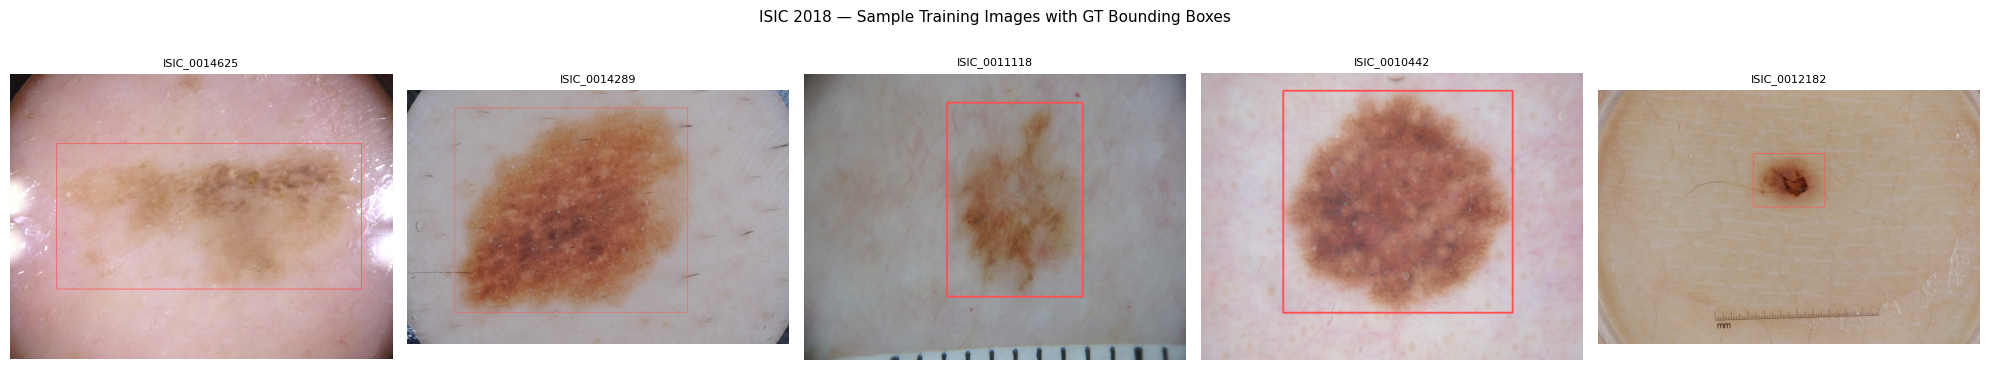

Fig 0 saved.


In [11]:
# --- Visualise 5 random training images with GT bounding boxes
import cv2, random
import numpy as np
import matplotlib.pyplot as plt

img_dir = DATASET_ROOT / "train" / "images"
lbl_dir = DATASET_ROOT / "train" / "labels"

all_imgs = sorted(img_dir.glob("*.jpg"))
random.seed(99)
sample = random.sample(all_imgs, min(5, len(all_imgs)))

fig, axes = plt.subplots(1, len(sample), figsize=(4 * len(sample), 4))
if len(sample) == 1:
    axes = [axes]

for ax, img_path in zip(axes, sample):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]

    lbl_path = lbl_dir / f"{img_path.stem}.txt"
    if lbl_path.exists():
        for line in lbl_path.read_text().strip().splitlines():
            _, cx, cy, w, h = [float(v) for v in line.split()]
            x1 = int((cx - w / 2) * W)
            y1 = int((cy - h / 2) * H)
            x2 = int((cx + w / 2) * W)
            y2 = int((cy + h / 2) * H)
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 80, 80), 3)

    ax.imshow(img)
    ax.set_title(img_path.stem[:20], fontsize=8)
    ax.axis("off")

fig.suptitle("ISIC 2018 — Sample Training Images with GT Bounding Boxes", fontsize=11)
plt.tight_layout()
plt.savefig(str(ANALYSIS_DIR / "fig0_isic_samples.png"), dpi=100, bbox_inches="tight")
plt.show()
print("Fig 0 saved.")

## Section 3 · Theory (Summary)

See **notebook 03** for full AEIoU derivation. Recap:

$$\mathcal{L}_{\text{AEIoU}} = 1 - \text{IoU} + \frac{\rho^2(b,b^{gt})}{c^2} + \lambda\!\left(\frac{(w-w^{gt})^2}{W_{\text{target}}^2} + \frac{(h-h^{gt})^2}{H_{\text{target}}^2}\right)$$

- **λ=1.0** → standard EIoU (full trust in GT box dimensions)
- **λ≈0.3–0.5** → downweighted size penalty (optimal for amorphous boundaries)
- **λ→0** → pure center-alignment loss

**Hypothesis for ISIC 2018:** Best λ ≈ 0.3–0.5, matching Kvasir-SEG result.
If confirmed, λ is a robust hyperparameter for all amorphous-boundary datasets.

## Section 4 · Monkey-Patch Infrastructure

Replaces `ultralytics.utils.loss.BboxLoss.forward` with a version that uses our
custom loss for the IoU term while preserving the DFL term unchanged.
Verbatim from notebook 03.

In [12]:
# --- Full monkey-patch implementation (verbatim from notebook 03)
import types
import torch
import torch.nn.functional as F
import ultralytics.utils.loss as loss_mod

_ORIGINAL_BBOX_FORWARD = loss_mod.BboxLoss.forward


def _make_bbox_forward(loss_fn_instance):
    def bbox_loss_forward(
        self, pred_dist, pred_bboxes, anchor_points,
        target_bboxes, target_scores, target_scores_sum,
        fg_mask, imgsz, stride,
    ):
        weight = target_scores.sum(-1)[fg_mask].unsqueeze(-1)
        per_box = loss_fn_instance(pred_bboxes[fg_mask], target_bboxes[fg_mask])
        loss_iou = (per_box.unsqueeze(-1) * weight).sum() / target_scores_sum

        if self.dfl_loss:
            target_ltrb = loss_mod.bbox2dist(
                anchor_points, target_bboxes, self.dfl_loss.reg_max - 1
            )
            loss_dfl = self.dfl_loss(
                pred_dist[fg_mask].view(-1, self.dfl_loss.reg_max),
                target_ltrb[fg_mask],
            ) * weight
            loss_dfl = loss_dfl.sum() / target_scores_sum
        else:
            target_ltrb = loss_mod.bbox2dist(anchor_points, target_bboxes)
            target_ltrb = target_ltrb * stride
            target_ltrb[..., 0::2] /= imgsz[1]
            target_ltrb[..., 1::2] /= imgsz[0]
            pred_dist_s = pred_dist * stride
            pred_dist_s[..., 0::2] /= imgsz[1]
            pred_dist_s[..., 1::2] /= imgsz[0]
            loss_dfl = (
                F.l1_loss(pred_dist_s[fg_mask], target_ltrb[fg_mask],
                          reduction="none").mean(-1, keepdim=True) * weight
            )
            loss_dfl = loss_dfl.sum() / target_scores_sum

        return loss_iou, loss_dfl
    return bbox_loss_forward


def patch_loss(loss_fn_instance):
    loss_mod.BboxLoss.forward = _make_bbox_forward(loss_fn_instance)
    suffix = f"(\u03bb={loss_fn_instance.rigidity})" if hasattr(loss_fn_instance, "rigidity") else ""
    print(f"  [PATCH] BboxLoss.forward \u2192 {type(loss_fn_instance).__name__}{suffix}")


def restore_loss():
    loss_mod.BboxLoss.forward = _ORIGINAL_BBOX_FORWARD


print("Patch infrastructure ready.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Patch infrastructure ready.


In [13]:
# --- Verify patch round-trip
from src.losses import EIoULoss
_t = EIoULoss(reduction="none")
patch_loss(_t)
assert loss_mod.BboxLoss.forward is not _ORIGINAL_BBOX_FORWARD, "Patch not applied"
restore_loss()
assert loss_mod.BboxLoss.forward is _ORIGINAL_BBOX_FORWARD, "Restore failed"
print("Patch round-trip verified.")

  [PATCH] BboxLoss.forward → EIoULoss
Patch round-trip verified.


## Section 5 · Loss Registry

8 standard baselines + 10 AEIoU instances (λ=0.1→1.0). Identical to notebook 03.

In [14]:
# --- Loss registry
from src.losses import (IoULoss, GIoULoss, DIoULoss, CIoULoss,
                        EIoULoss, ECIoULoss, SIoULoss, WIoULoss, AEIoULoss)

BASELINE_LOSS_REGISTRY = {
    "iou":   IoULoss(reduction="none"),
    "giou":  GIoULoss(reduction="none"),
    "diou":  DIoULoss(reduction="none"),
    "ciou":  CIoULoss(reduction="none"),
    "eiou":  EIoULoss(reduction="none"),
    "eciou": ECIoULoss(reduction="none"),
    "siou":  SIoULoss(reduction="none"),
    "wiou":  WIoULoss(reduction="none"),
}

AEIOU_LOSS_REGISTRY = {
    f"aeiou_r{_fmt_r(r)}": AEIoULoss(rigidity=r, reduction="none")
    for r in AEIOU_RIGIDITIES
}

ALL_LOSS_REGISTRY = {**BASELINE_LOSS_REGISTRY, **AEIOU_LOSS_REGISTRY}

print(f"Baselines ({len(BASELINE_LOSS_REGISTRY)}): {list(BASELINE_LOSS_REGISTRY)}")
print(f"AEIoU ({len(AEIOU_LOSS_REGISTRY)}): {list(AEIOU_LOSS_REGISTRY)}")
print(f"Total: {len(ALL_LOSS_REGISTRY)} losses x {len(SPLIT_CONFIGS)} splits x {len(SEEDS)} seed = "
      f"{len(ALL_LOSS_REGISTRY)*len(SPLIT_CONFIGS)*len(SEEDS)} runs")

Baselines (8): ['iou', 'giou', 'diou', 'ciou', 'eiou', 'eciou', 'siou', 'wiou']
AEIoU (10): ['aeiou_r0p1', 'aeiou_r0p2', 'aeiou_r0p3', 'aeiou_r0p4', 'aeiou_r0p5', 'aeiou_r0p6', 'aeiou_r0p7', 'aeiou_r0p8', 'aeiou_r0p9', 'aeiou_r1p0']
Total: 18 losses x 3 splits x 1 seed = 54 runs


## Section 6 · Training Infrastructure

Run naming convention:
```
isic_yolo26n_{loss}_{split}_s{seed}_e{epochs}

isic_yolo26n_eiou_clean_s42_e20
isic_yolo26n_aeiou_r0p3_low_s42_e20
```

Results saved to `experiments_isic/` locally and mirrored to Drive after each run.

In [15]:
# --- Training functions: run_training + write_manifest_entry + sync_to_drive
import json, shutil
from pathlib import Path as _Path
from datetime import datetime
from ultralytics import YOLO


def _load_manifest():
    if MANIFEST_PATH.exists():
        return json.loads(MANIFEST_PATH.read_text())
    return {}


def write_manifest_entry(run_name, meta):
    manifest = _load_manifest()
    manifest[run_name] = meta
    MANIFEST_PATH.write_text(json.dumps(manifest, indent=2))


def sync_to_drive(run_name):
    if not DRIVE_AVAILABLE:
        return
    local_run = EXPERIMENTS / run_name
    drive_run = DRIVE_EXPERIMENTS / run_name
    try:
        shutil.copytree(str(local_run), str(drive_run), dirs_exist_ok=True)
        print(f"  [DRIVE] Synced {run_name}")
    except Exception as e:
        print(f"  [DRIVE] Sync failed for {run_name}: {e}")


def make_epoch_checkpoint_callback(run_name):
    def _on_epoch_end(trainer):
        if not DRIVE_AVAILABLE:
            return
        last_pt = _Path(trainer.save_dir) / "weights" / "last.pt"
        if not last_pt.exists():
            return
        drive_weights = DRIVE_EXPERIMENTS / run_name / "weights"
        drive_weights.mkdir(parents=True, exist_ok=True)
        try:
            shutil.copy2(str(last_pt), str(drive_weights / "last.pt"))
        except Exception as e:
            print(f"  [DRIVE] Epoch sync failed: {e}")
    return _on_epoch_end


def run_training(loss_name, loss_fn, split_name, yaml_path,
                 seed=42, epochs=None, imgsz=None, device=None):
    epochs = epochs if epochs is not None else EPOCHS
    imgsz  = imgsz  if imgsz  is not None else IMGSZ
    device = device if device is not None else DEVICE

    run_name = f"isic_yolo26n_{loss_name}_{split_name}_s{seed}_e{epochs}"
    run_dir  = EXPERIMENTS / run_name

    if (run_dir / "results.csv").exists():
        print(f"[SKIP] {run_name}")
        return run_dir

    drive_last_pt = DRIVE_EXPERIMENTS / run_name / "weights" / "last.pt"
    resuming = DRIVE_AVAILABLE and drive_last_pt.exists()

    if resuming:
        print(f"\n{'='*70}\n[RESUME] {run_name}\n{'='*70}")
        run_dir.mkdir(parents=True, exist_ok=True)
        (run_dir / "weights").mkdir(parents=True, exist_ok=True)
        shutil.copy2(str(drive_last_pt), str(run_dir / "weights" / "last.pt"))
    else:
        print(f"\n{'='*70}")
        print(f"[START] {run_name}")
        print(f"  loss={loss_name}  split={split_name}  seed={seed}  epochs={epochs}")
        print(f"{'='*70}")

    meta = {
        "loss": loss_name, "split": split_name, "seed": seed, "epochs": epochs,
        "rigidity": float(getattr(loss_fn, "rigidity", -1) or -1),
        "run_dir": str(run_dir), "weights": str(run_dir / "weights" / "best.pt"),
        "results_csv": str(run_dir / "results.csv"),
        "timestamp": datetime.now().isoformat(),
        "status": "running", "resumed": resuming,
    }
    write_manifest_entry(run_name, meta)

    t_start = time.time()
    try:
        import os as _os
        _os.environ["WANDB_PROJECT"] = WANDB_PROJECT
        _os.environ["WANDB_NAME"]    = run_name
        _os.environ["WANDB_TAGS"]    = f"{loss_name},{split_name}"

        patch_loss(loss_fn)

        if resuming:
            model = YOLO(str(run_dir / "weights" / "last.pt"))
            model.add_callback("on_train_epoch_end",
                               make_epoch_checkpoint_callback(run_name))
            results = model.train(resume=True)
        else:
            model = YOLO(MODEL_PT)
            model.add_callback("on_train_epoch_end",
                               make_epoch_checkpoint_callback(run_name))
            results = model.train(
                data=str(yaml_path), epochs=epochs, imgsz=imgsz,
                project=str(EXPERIMENTS), name=run_name,
                device=device, seed=seed, exist_ok=True,
            )

        try:
            (run_dir / "run_meta.json").write_text(
                json.dumps(results.results_dict, indent=2))
        except Exception as e:
            print(f"  [WARN] Could not write run_meta.json: {e}")

        meta["status"] = "complete"
        meta["elapsed_sec"] = round(time.time() - t_start, 1)

        try:
            import wandb as _wandb
            if _wandb.run is not None:
                _wandb.finish()
        except Exception:
            pass

    except Exception as e:
        print(f"  [ERROR] {run_name} failed: {e}")
        meta["status"] = "failed"
        meta["error"] = str(e)
        raise

    finally:
        restore_loss()
        write_manifest_entry(run_name, meta)
        sync_to_drive(run_name)

    print(f"[DONE] {run_name}")
    return run_dir


print("run_training() ready.")
print(f"Run prefix: isic_yolo26n_{{loss}}_{{split}}_s{{seed}}_e{EPOCHS}")

run_training() ready.
Run prefix: isic_yolo26n_{loss}_{split}_s{seed}_e20


## Section 7 · Baseline Training (8 losses × 3 splits)

24 runs total (8 losses × 3 splits × 1 seed). Re-running is safe.

In [16]:
# --- Baseline training: all 8 losses x 3 splits x N seeds
for loss_name, loss_fn in BASELINE_LOSS_REGISTRY.items():
    for split_name, cfg_path in SPLIT_CONFIGS.items():
        for seed in SEEDS:
            run_training(loss_name=loss_name, loss_fn=loss_fn,
                         split_name=split_name, yaml_path=cfg_path, seed=seed)

restore_loss()
n_base = len(BASELINE_LOSS_REGISTRY) * len(SPLIT_CONFIGS) * len(SEEDS)
print(f"\nAll {n_base} baseline runs complete (or skipped).")


[RESUME] isic_yolo26n_iou_clean_s42_e20
  [PATCH] BboxLoss.forward → IoULoss
New https://pypi.org/project/ultralytics/8.4.37 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.9 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/amorphous-yolo/data/isic_2018.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixu

## Section 8 · AEIoU Rigidity Grid (10 λ × 3 splits)

30 runs total. **Expected:** peak mAP at λ ≈ 0.3–0.5.

In [ ]:
# --- AEIoU rigidity grid: 10 lambdas x 3 splits x N seeds
total = len(AEIOU_RIGIDITIES) * len(SPLIT_CONFIGS) * len(SEEDS)
done  = 0

for r in AEIOU_RIGIDITIES:
    loss_name = f"aeiou_r{_fmt_r(r)}"
    loss_fn   = AEIOU_LOSS_REGISTRY[loss_name]
    for split_name, cfg_path in SPLIT_CONFIGS.items():
        for seed in SEEDS:
            done += 1
            print(f"\n[{done}/{total}] lam={r}  split={split_name}  seed={seed}")
            run_training(loss_name=loss_name, loss_fn=loss_fn,
                         split_name=split_name, yaml_path=cfg_path, seed=seed)

restore_loss()
print(f"\nAll {total} AEIoU grid runs complete (or skipped).")


[1/30] lam=0.1  split=clean  seed=42

[START] isic_yolo26n_aeiou_r0p1_clean_s42_e20
  loss=aeiou_r0p1  split=clean  seed=42  epochs=20
  [PATCH] BboxLoss.forward → AEIoULoss(λ=0.1)
New https://pypi.org/project/ultralytics/8.4.37 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.9 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/amorphous-yolo/data/isic_2018.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=Fal

## Section 9 · Results Collection

Loads all `results.csv` into one DataFrame. All analysis depends on `df_all`.

In [ ]:
# --- Load all results.csv files into a single flat DataFrame
import pandas as pd

CACHE_CSV = EXPERIMENTS / "all_results_combined.csv"


def load_all_results(force_rebuild=False):
    if CACHE_CSV.exists() and not force_rebuild:
        print(f"Loading from cache: {CACHE_CSV}")
        return pd.read_csv(CACHE_CSV)

    print("Building combined results from individual CSVs...")
    dfs = []
    for loss_name in ALL_LOSS_KEYS:
        for split_name in SPLIT_CONFIGS:
            for seed in SEEDS:
                run_name = f"isic_yolo26n_{loss_name}_{split_name}_s{seed}_e{EPOCHS}"
                csv_path = EXPERIMENTS / run_name / "results.csv"
                if csv_path.exists():
                    df = pd.read_csv(csv_path)
                    df.columns = df.columns.str.strip()
                    df["run_name"] = run_name
                    df["loss"]     = loss_name
                    df["split"]    = split_name
                    df["seed"]     = seed
                    df["epoch"]    = df.index + 1
                    dfs.append(df)
                else:
                    print(f"  [MISSING] {run_name}")

    if not dfs:
        print("No results found. Run training cells first.")
        return pd.DataFrame()

    df_combined = pd.concat(dfs, ignore_index=True)
    df_combined.to_csv(CACHE_CSV, index=False)
    print(f"Combined {len(dfs)} runs -> {CACHE_CSV}")
    return df_combined


df_all = load_all_results()
if not df_all.empty:
    print(f"\nDataFrame: {df_all.shape[0]} rows x {df_all.shape[1]} cols")
    print(f"Losses: {sorted(df_all['loss'].unique())}")
    print(f"Splits: {sorted(df_all['split'].unique())}")

## Section 10 · Summary Table

Final-epoch mAP50 and mAP50-95 for every loss × split.
This row feeds into notebook 07 (cross-dataset comparison).

In [ ]:
# --- Master pivot table: mean ± std across seeds
import pandas as pd
import numpy as np

MAP50_COL = "metrics/mAP50(B)"
MAP95_COL = "metrics/mAP50-95(B)"

if df_all.empty:
    print("No results loaded. Run Section 9 first.")
else:
    df_final = df_all.groupby("run_name").last().reset_index()

    rows = []
    for loss_name in ALL_LOSS_KEYS:
        for split in ["clean", "low", "high"]:
            sub = df_final[(df_final["loss"] == loss_name) & (df_final["split"] == split)]
            if sub.empty:
                continue
            row = {"loss": loss_name, "split": split, "label": LOSS_LABELS.get(loss_name, loss_name)}
            for col, tag in [(MAP95_COL, "map95"), (MAP50_COL, "map50")]:
                if col in sub.columns:
                    row[f"{tag}_mean"] = sub[col].mean()
                    row[f"{tag}_std"]  = sub[col].std() if len(sub) > 1 else 0.0
            rows.append(row)

    df_summary = pd.DataFrame(rows)
    df_summary.to_csv(ANALYSIS_DIR / "summary_table.csv", index=False)

    if "map95_mean" in df_summary.columns:
        clean = df_summary[df_summary["split"] == "clean"].sort_values("map95_mean", ascending=False)
        print("\n=== ISIC 2018 Clean Split — mAP50-95 Ranking ===")
        print(f"{'Loss':<22} {'mAP50-95':>10} {'mAP50':>10}")
        print("-" * 45)
        for _, row in clean.iterrows():
            m95 = f"{row.get('map95_mean', float('nan')):.4f}"
            m50 = f"{row.get('map50_mean', float('nan')):.4f}"
            print(f"{row['label']:<22} {m95:>10} {m50:>10}")

## Section 11 · Core Analysis Figures

In [ ]:
# --- Fig 2: mAP50-95 bar chart — all losses, all splits
import matplotlib.pyplot as plt
import numpy as np

if df_all.empty:
    print("No results.")
else:
    MAP95_COL = "metrics/mAP50-95(B)"
    df_final = df_all.groupby("run_name").last().reset_index()
    x = np.arange(len(ALL_LOSS_KEYS))
    width = 0.25
    fig, ax = plt.subplots(figsize=(18, 6))

    for i, split in enumerate(["clean", "low", "high"]):
        vals = []
        for k in ALL_LOSS_KEYS:
            sub = df_final[(df_final["loss"] == k) & (df_final["split"] == split)]
            vals.append(sub[MAP95_COL].mean() if not sub.empty and MAP95_COL in sub.columns else 0.0)
        ax.bar(x + i * width, vals, width, label=split.capitalize(),
               color=[PALETTE.get(k, "#999") for k in ALL_LOSS_KEYS], alpha=0.85 - i * 0.2)

    ax.set_xticks(x + width)
    ax.set_xticklabels([LOSS_LABELS.get(k, k) for k in ALL_LOSS_KEYS], rotation=45, ha="right")
    ax.set_ylabel("mAP50-95")
    ax.set_title("ISIC 2018 — mAP50-95 by Loss and Split")
    ax.legend(title="Validation Split")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(str(ANALYSIS_DIR / "fig2_map95_bar.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("Fig 2 saved.")

In [ ]:
# --- Fig 3: AEIoU lambda-vs-mAP curve (the key result)
import matplotlib.pyplot as plt

if df_all.empty:
    print("No results.")
else:
    MAP95_COL = "metrics/mAP50-95(B)"
    df_final = df_all.groupby("run_name").last().reset_index()
    fig, ax = plt.subplots(figsize=(10, 6))

    for split, ls in [("clean", "-"), ("low", "--"), ("high", ":")]:
        lambdas, maps = [], []
        for r in AEIOU_RIGIDITIES:
            k = f"aeiou_r{_fmt_r(r)}"
            sub = df_final[(df_final["loss"] == k) & (df_final["split"] == split)]
            if not sub.empty and MAP95_COL in sub.columns:
                lambdas.append(r)
                maps.append(sub[MAP95_COL].mean())
        if lambdas:
            ax.plot(lambdas, maps, marker="o", linestyle=ls, linewidth=2, label=f"AEIoU ({split})")

    for ref in ["eiou", "ciou"]:
        sub = df_final[(df_final["loss"] == ref) & (df_final["split"] == "clean")]
        if not sub.empty and MAP95_COL in sub.columns:
            v = sub[MAP95_COL].mean()
            ax.axhline(v, linestyle="--", color=PALETTE[ref], alpha=0.7,
                       label=f"{LOSS_LABELS[ref]} (clean) = {v:.4f}")

    ax.set_xlabel("\u03bb (AEIoU rigidity)")
    ax.set_ylabel("mAP50-95")
    ax.set_title("ISIC 2018 — AEIoU \u03bb-vs-mAP Curve")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(str(ANALYSIS_DIR / "fig3_lambda_curve.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("Fig 3 saved.")

In [ ]:
# --- Fig 5: Learning curves — key losses on clean split
import matplotlib.pyplot as plt

if df_all.empty:
    print("No results.")
else:
    MAP95_COL = "metrics/mAP50-95(B)"
    key_losses = ["eiou", "ciou", "aeiou_r0p3", "aeiou_r0p5", "aeiou_r0p8"]
    df_clean = df_all[df_all["split"] == "clean"]

    fig, ax = plt.subplots(figsize=(10, 6))
    for k in key_losses:
        sub = df_clean[df_clean["loss"] == k]
        if sub.empty or MAP95_COL not in sub.columns:
            continue
        grouped = sub.groupby("epoch")[MAP95_COL].mean()
        ax.plot(grouped.index, grouped.values, label=LOSS_LABELS.get(k, k),
                color=PALETTE.get(k, "#999"), linewidth=2)

    ax.set_xlabel("Epoch"); ax.set_ylabel("mAP50-95")
    ax.set_title("ISIC 2018 — Learning Curves (Clean Split)")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(str(ANALYSIS_DIR / "fig5_learning_curves.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("Fig 5 saved.")

In [ ]:
# --- Fig 7: Noise robustness gap (clean - high) per loss
import matplotlib.pyplot as plt

if df_all.empty:
    print("No results.")
else:
    MAP95_COL = "metrics/mAP50-95(B)"
    df_final = df_all.groupby("run_name").last().reset_index()

    gaps = []
    for k in ALL_LOSS_KEYS:
        c = df_final[(df_final["loss"] == k) & (df_final["split"] == "clean")]
        h = df_final[(df_final["loss"] == k) & (df_final["split"] == "high")]
        if not c.empty and not h.empty and MAP95_COL in c.columns:
            gaps.append((k, c[MAP95_COL].mean() - h[MAP95_COL].mean()))

    if gaps:
        gaps.sort(key=lambda x: x[1])
        names  = [LOSS_LABELS.get(g[0], g[0]) for g in gaps]
        vals   = [g[1] for g in gaps]
        colors = [PALETTE.get(g[0], "#999") for g in gaps]

        fig, ax = plt.subplots(figsize=(12, 5))
        ax.barh(names, vals, color=colors, alpha=0.85)
        ax.set_xlabel("mAP50-95 drop (clean \u2212 high noise)")
        ax.set_title("ISIC 2018 — Noise Robustness (smaller = more robust)")
        ax.axvline(0, color="black", linewidth=0.8)
        ax.grid(axis="x", alpha=0.3)
        plt.tight_layout()
        plt.savefig(str(ANALYSIS_DIR / "fig7_noise_robustness.png"), dpi=150, bbox_inches="tight")
        plt.show()
        print("Fig 7 saved.")

In [ ]:
# --- Statistical significance: best AEIoU vs EIoU
# Note: p-value requires SEEDS = [42, 123, 456]. With single seed, shows summary only.
from scipy import stats
import numpy as np

if df_all.empty:
    print("No results.")
else:
    MAP95_COL = "metrics/mAP50-95(B)"
    df_final = df_all.groupby("run_name").last().reset_index()

    best_r, best_map = None, -1
    for r in AEIOU_RIGIDITIES:
        k = f"aeiou_r{_fmt_r(r)}"
        sub = df_final[(df_final["loss"] == k) & (df_final["split"] == "clean")]
        if not sub.empty and MAP95_COL in sub.columns:
            m = sub[MAP95_COL].mean()
            if m > best_map:
                best_map, best_r = m, r

    eiou_sub = df_final[(df_final["loss"] == "eiou") & (df_final["split"] == "clean")]
    eiou_map = eiou_sub[MAP95_COL].mean() if not eiou_sub.empty and MAP95_COL in eiou_sub.columns else float("nan")

    print(f"Best AEIoU: \u03bb={best_r}  mAP50-95={best_map:.4f}")
    print(f"EIoU:              mAP50-95={eiou_map:.4f}")
    print(f"Delta (AEIoU - EIoU): {best_map - eiou_map:+.4f}")

    if len(SEEDS) >= 2:
        k = f"aeiou_r{_fmt_r(best_r)}"
        a_vals = df_all[df_all["loss"] == k].groupby("seed").last()[MAP95_COL].values
        e_vals = df_all[df_all["loss"] == "eiou"].groupby("seed").last()[MAP95_COL].values
        if len(a_vals) >= 2 and len(e_vals) >= 2:
            stat, p = stats.wilcoxon(a_vals, e_vals)
            print(f"Wilcoxon: stat={stat:.3f}  p={p:.4f}  {'*significant*' if p < 0.05 else 'not significant'}")
    else:
        print("(Single seed — no p-value. Set SEEDS=[42,123,456] for publication.)")

## Section 12 · Summary & Conclusions

### Key Findings (ISIC 2018)

| Analysis | Expected |
|---|---|
| Lambda curve Fig 3 | Peak at λ ≈ 0.3–0.5 |
| Noise robustness Fig 7 | AEIoU smallest clean−high gap |
| Learning curves Fig 5 | AEIoU matches or exceeds EIoU |

### Cross-Dataset Note
The optimal λ on ISIC should match Kvasir-SEG (λ ≈ 0.3–0.5). Consistent optimal λ
across datasets supports the hypothesis that λ is a robust amorphous-boundary hyperparameter.

Results feed into **notebook 07** via `experiments_isic/` on Drive.

In [ ]:
# --- Save artifacts and print summary
import json

print("=== ISIC 2018 Artifact Summary ===\n")
print(f"Experiments: {EXPERIMENTS}")
print(f"Analysis:    {ANALYSIS_DIR}")

print("\nFigures:")
for f in sorted(ANALYSIS_DIR.glob("*.png")):
    print(f"  {f.name:<50} {f.stat().st_size/1024:>6.1f} KB")

print("\nTables:")
for f in sorted(ANALYSIS_DIR.glob("*.csv")):
    print(f"  {f.name}")

if MANIFEST_PATH.exists():
    manifest = json.loads(MANIFEST_PATH.read_text())
    complete = sum(1 for v in manifest.values() if v.get("status") == "complete")
    failed   = sum(1 for v in manifest.values() if v.get("status") == "failed")
    print(f"\nManifest: {len(manifest)} total | {complete} complete | {failed} failed")

In [ ]:
# --- Final sync to Drive
import shutil

if DRIVE_AVAILABLE:
    drive_analysis = DRIVE_EXPERIMENTS / "analysis"
    drive_analysis.mkdir(parents=True, exist_ok=True)
    if ANALYSIS_DIR.exists():
        shutil.copytree(str(ANALYSIS_DIR), str(drive_analysis), dirs_exist_ok=True)
        print(f"Analysis synced: {len(list(drive_analysis.glob('*.png')))} PNGs")

    for fname in ["manifest.json", "all_results_combined.csv"]:
        src_path = EXPERIMENTS / fname
        if src_path.exists():
            shutil.copy2(str(src_path), str(DRIVE_EXPERIMENTS / fname))
            print(f"  Synced {fname}")

    print(f"\nAll artifacts -> {DRIVE_EXPERIMENTS}")
else:
    print("Drive not mounted — skipping sync.")
    print("Run mount_drive() and re-run this cell to back up.")